# Fraud Payment Detection - 종합 분류 모델 비교 (모범 답안)

이 파일은 결제 사기 탐지 문제를 여러 분류 모델로 해결하고 성능을 비교하는 종합 문제입니다.
수강생들이 자신의 문제 풀이와 비교하여 학습할 수 있도록 작성되었습니다.

**학습 목표:**
- 여러 분류 모델(Logistic Regression, KNN, Decision Tree, Random Forest)을 동일한 데이터에 적용
- 각 모델의 성능을 비교하고 분석
- 사기 탐지 문제에 가장 적합한 모델 선택

**데이터 설명:**
- accountAgeDays : 계정이 생성된 기간 (일)
- numItems : 구매한 항목 수
- localTime : 결제가 이루어진 시기 (부동 숫자로 변환 됨)
- paymentMethod : 결제 방법 (페이팔, 상점 신용 카드 또는 신용 카드)
- paymentMethodAgeDays : 결제가 완료된 기간 (일)
- label 0 - 정상, 1 - fraud

## 1. 데이터 로드 및 전처리

필요한 라이브러리를 import 합니다. 여러 분류 모델과 평가 지표를 사용합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score, 
                          precision_score, recall_score, roc_auc_score)
import seaborn as sns

결제 사기 탐지 데이터셋을 로드합니다. 이 데이터로 정상 결제와 사기 결제를 구분하는 모델을 학습합니다.

In [2]:
df = pd.read_csv("datasets/payment_fraud.csv")
df.sample(5)

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,label
13299,17,1,4.962055,creditcard,0.000000,0
37443,2,1,4.748314,paypal,1.902778,0
32115,1518,1,5.034622,creditcard,16.091667,0
10993,2000,1,4.742303,paypal,16.108333,0
1845,406,1,4.748314,paypal,0.000000,0


라벨의 분포를 확인합니다. 정상(0)과 사기(1)의 비율을 확인할 수 있습니다. 데이터 불균형이 있을 수 있습니다.

In [19]:
df.label.value_counts()

label
0    38661
1      560
Name: count, dtype: int64

데이터 불균형 문제를 해결하기 위해 사기(1) 샘플을 모두 선택하고, 정상(0) 샘플은 일부만 샘플링합니다.

In [20]:
df1 = df[df.label == 1]
df1.shape

(560, 6)

정상 결제 데이터에서 1000개를 무작위로 샘플링합니다. 이렇게 하면 클래스 불균형을 완화할 수 있습니다.

In [21]:
df0 = df[df.label == 0].sample(1000, random_state=0)
df0.shape

(1000, 6)

샘플링된 정상 데이터와 전체 사기 데이터를 합쳐서 새로운 데이터셋을 만듭니다.

In [22]:
df_new = pd.concat([df0, df1])
df_new.shape

(1560, 6)

결제 방법을 원-핫 인코딩으로 변환합니다. 각 결제 방법이 별도의 이진 특성으로 변환됩니다.

In [23]:
df_new = pd.get_dummies(df_new, columns=['paymentMethod'])

원-핫 인코딩이 적용된 데이터를 확인합니다. paymentMethod 컬럼이 여러 개의 이진 컬럼으로 분리되었습니다.

In [24]:
df_new.sample(5)

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label,paymentMethod_creditcard,paymentMethod_paypal,paymentMethod_storecredit
18045,1701,1,5.034622,0.000000,0,False,True,False
7064,1,1,4.742303,0.000000,1,True,False,False
33375,1,2,4.057414,0.000000,1,True,False,False
15495,1,1,4.748314,0.000000,1,True,False,False
28569,2000,1,4.921318,286.224306,0,True,False,False


특성과 라벨을 분리합니다. pop() 메서드를 사용하여 label 컬럼을 제거하면서 동시에 y로 할당합니다.

In [25]:
y = df_new.pop('label')
X = df_new.values

데이터를 훈련용과 테스트용으로 분할합니다. test_size=0.2로 80%는 훈련, 20%는 테스트 데이터로 나뉩니다.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1248, 7), (312, 7), (1248,), (312,))

특성 스케일링을 수행합니다. StandardScaler를 사용하여 모든 특성을 평균 0, 표준편차 1로 정규화합니다.
일부 모델(KNN, Logistic Regression)은 스케일링이 중요합니다.

In [27]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## 2. 여러 분류 모델 적용 및 평가

### 2.1 Logistic Regression

로지스틱 회귀 모델을 생성하고 훈련 데이터로 학습시킵니다. 선형 분류 모델로 빠르고 해석이 용이합니다.

In [28]:
lr_classifier = LogisticRegression(solver='liblinear', random_state=0, max_iter=1000)
lr_classifier.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

테스트 데이터에 대한 예측을 수행합니다.

In [29]:
y_pred_lr = lr_classifier.predict(X_test_scaled)

print("Logistic Regression 예측 결과 (일부):", y_pred_lr[:10])
print(f"테스트 세트의 실제 사기 거래 수: {sum(y_test)}")
print(f"모델이 예측한 사기 거래 수: {sum(y_pred_lr)}")
print(f"정확도: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression 예측 결과 (일부): [0 1 0 0 0 1 0 1 1 0]
테스트 세트의 실제 사기 거래 수: 108
모델이 예측한 사기 거래 수: 140
정확도: 0.8910


### 2.2 K-Nearest Neighbors (KNN)

KNN 분류기를 생성하고 학습시킵니다. KNN은 거리 기반 분류 모델로, 스케일링이 중요합니다.

In [30]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


테스트 데이터에 대한 예측을 수행합니다.

In [31]:
y_pred_knn = knn_classifier.predict(X_test_scaled)

print("KNN 예측 결과 (일부):", y_pred_knn[:10])
print(f"테스트 세트의 실제 사기 거래 수: {sum(y_test)}")
print(f"모델이 예측한 사기 거래 수: {sum(y_pred_knn)}")
print(f"정확도: {accuracy_score(y_test, y_pred_knn):.4f}")

KNN 예측 결과 (일부): [0 1 0 1 0 0 0 1 1 0]
테스트 세트의 실제 사기 거래 수: 108
모델이 예측한 사기 거래 수: 130
정확도: 0.9231


### 2.3 Decision Tree

Decision Tree 분류기를 생성하고 학습시킵니다. 트리 모델은 스케일링이 필요 없으며, 해석이 용이합니다.

In [32]:
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=0, criterion='entropy')
dt_classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

테스트 데이터에 대한 예측을 수행합니다.

In [33]:
y_pred_dt = dt_classifier.predict(X_test)

print("Decision Tree 예측 결과 (일부):", y_pred_dt[:10])
print(f"테스트 세트의 실제 사기 거래 수: {sum(y_test)}")
print(f"모델이 예측한 사기 거래 수: {sum(y_pred_dt)}")
print(f"정확도: {accuracy_score(y_test, y_pred_dt):.4f}")

Decision Tree 예측 결과 (일부): [0 1 0 0 0 0 0 1 1 0]
테스트 세트의 실제 사기 거래 수: 108
모델이 예측한 사기 거래 수: 108
정확도: 1.0000


### 2.4 Random Forest

Random Forest 분류기를 생성하고 학습시킵니다. 여러 의사결정 트리를 앙상블하여 더 강건한 모델을 만듭니다.

In [34]:
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=0, 
)
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

테스트 데이터에 대한 예측을 수행합니다.

In [35]:
y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest 예측 결과 (일부):", y_pred_rf[:10])
print(f"테스트 세트의 실제 사기 거래 수: {sum(y_test)}")
print(f"모델이 예측한 사기 거래 수: {sum(y_pred_rf)}")
print(f"정확도: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest 예측 결과 (일부): [0 1 0 0 0 0 0 1 1 0]
테스트 세트의 실제 사기 거래 수: 108
모델이 예측한 사기 거래 수: 108
정확도: 1.0000


## 3. 모델 성능 비교

각 모델의 성능 지표를 계산하여 비교합니다. 사기 탐지에서는 Recall(재현율)이 특히 중요합니다.

In [36]:
models = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

results = []

for model_name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)
print("\n=== 모델 성능 비교 ===\n")
print(results_df.to_string(index=False))


=== 모델 성능 비교 ===

              Model  Accuracy  Precision   Recall  F1 Score
      Random Forest  1.000000   1.000000 1.000000  1.000000
      Decision Tree  1.000000   1.000000 1.000000  1.000000
                KNN  0.923077   0.823077 0.990741  0.899160
Logistic Regression  0.891026   0.764286 0.990741  0.862903


성능 지표를 시각화하여 비교합니다.

C:\Users\trimu\AppData\Local\Temp\ipykernel_1964\3212658455.py:12: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\trimu\AppData\Local\Temp\ipykernel_1964\3212658455.py:12: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\trimu\anaconda3\envs\sw_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\trimu\anaconda3\envs\sw_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


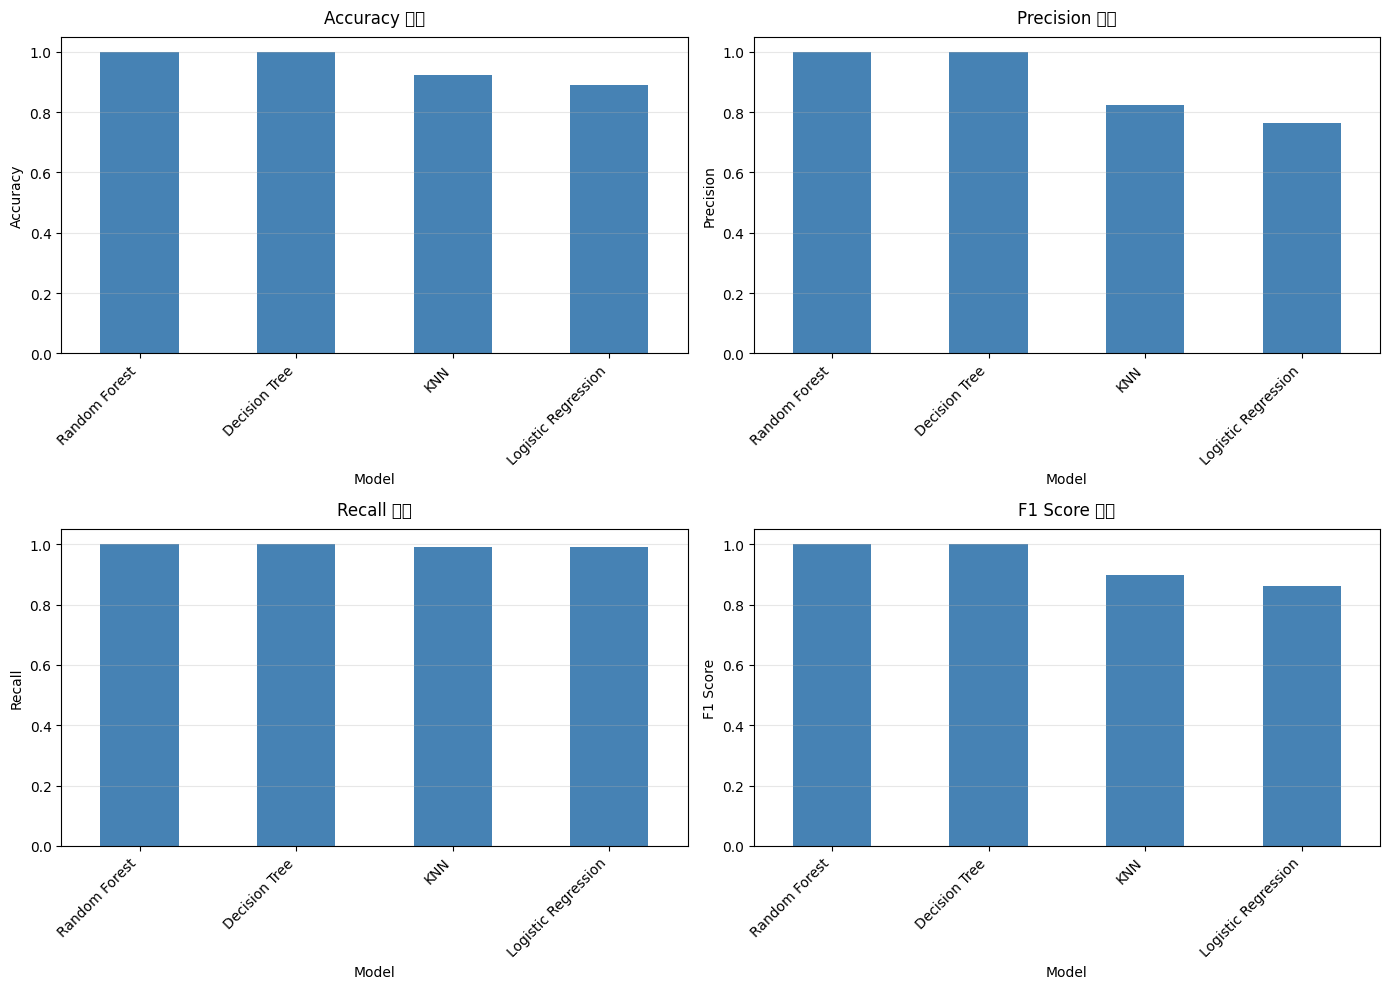

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    results_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False, color='steelblue')
    ax.set_title(f'{metric} 비교', fontsize=12, pad=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 혼동 행렬 비교

각 모델의 혼동 행렬을 시각화하여 비교합니다. 사기 탐지에서는 False Negative(사기를 놓치는 경우)를 최소화하는 것이 중요합니다.

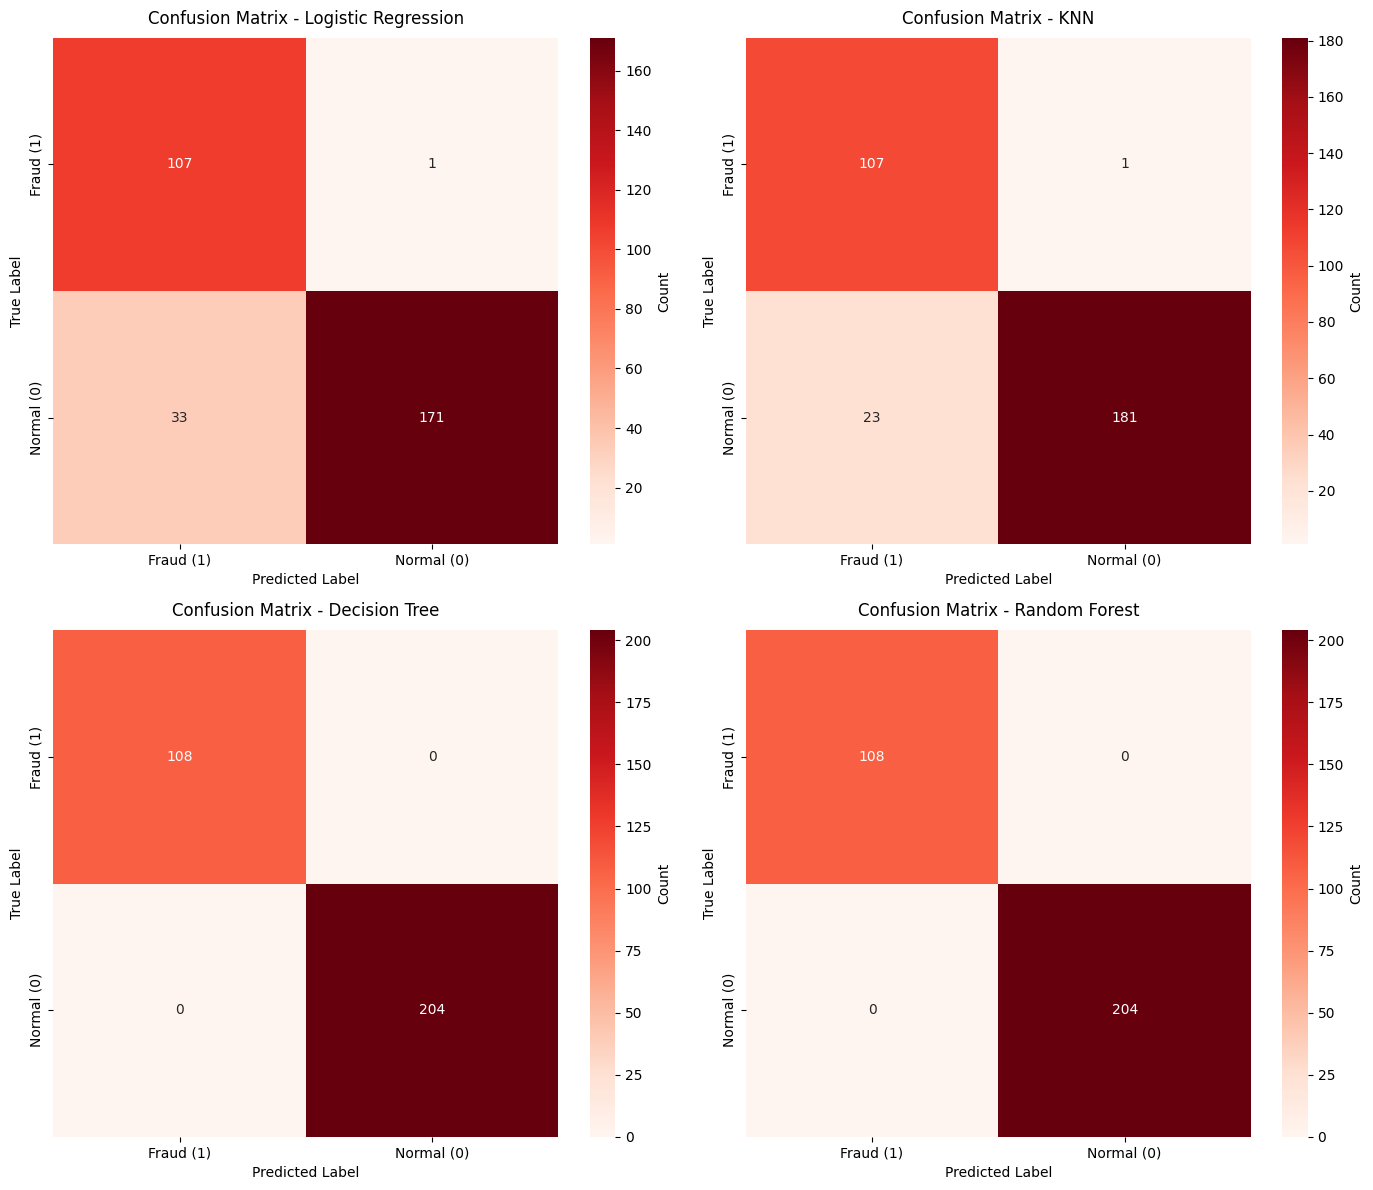

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

model_predictions = [
    ('Logistic Regression', y_pred_lr),
    ('KNN', y_pred_knn),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for idx, (model_name, y_pred) in enumerate(model_predictions):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Fraud (1)', 'Normal (0)'],
                yticklabels=['Fraud (1)', 'Normal (0)'],
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

## 5. 모델별 상세 평가

각 모델의 혼동 행렬을 상세히 분석합니다.

In [39]:
for model_name, y_pred in model_predictions:
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    print(f"\n=== {model_name} ===")
    print(f"Confusion Matrix:\n{cm}")
    print(f"True Positive (TP): {cm[0,0]} - 사기를 사기로 정확히 예측")
    print(f"False Positive (FP): {cm[0,1]} - 정상을 사기로 잘못 예측")
    print(f"False Negative (FN): {cm[1,0]} - 사기를 정상으로 잘못 예측 (위험!)")
    print(f"True Negative (TN): {cm[1,1]} - 정상을 정상으로 정확히 예측")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")


=== Logistic Regression ===
Confusion Matrix:
[[107   1]
 [ 33 171]]
True Positive (TP): 107 - 사기를 사기로 정확히 예측
False Positive (FP): 1 - 정상을 사기로 잘못 예측
False Negative (FN): 33 - 사기를 정상으로 잘못 예측 (위험!)
True Negative (TN): 171 - 정상을 정상으로 정확히 예측
Accuracy: 0.8910
Precision: 0.7643
Recall: 0.9907
F1 Score: 0.8629

=== KNN ===
Confusion Matrix:
[[107   1]
 [ 23 181]]
True Positive (TP): 107 - 사기를 사기로 정확히 예측
False Positive (FP): 1 - 정상을 사기로 잘못 예측
False Negative (FN): 23 - 사기를 정상으로 잘못 예측 (위험!)
True Negative (TN): 181 - 정상을 정상으로 정확히 예측
Accuracy: 0.9231
Precision: 0.8231
Recall: 0.9907
F1 Score: 0.8992

=== Decision Tree ===
Confusion Matrix:
[[108   0]
 [  0 204]]
True Positive (TP): 108 - 사기를 사기로 정확히 예측
False Positive (FP): 0 - 정상을 사기로 잘못 예측
False Negative (FN): 0 - 사기를 정상으로 잘못 예측 (위험!)
True Negative (TN): 204 - 정상을 정상으로 정확히 예측
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

=== Random Forest ===
Confusion Matrix:
[[108   0]
 [  0 204]]
True Positive (TP): 108 - 사기를 사기로 정확히 예측


## 6. 결론 및 모델 선택

각 모델의 특징과 사기 탐지에 대한 적합성을 분석합니다.

In [40]:
print("\n=== 모델별 특징 및 사기 탐지 적합성 ===\n")

print("1. Logistic Regression:")
print("   - 장점: 빠른 학습 속도, 해석 용이, 선형 관계 학습에 적합")
print("   - 단점: 복잡한 비선형 패턴 학습 어려움")
print("   - 사기 탐지: 기본적인 선형 패턴 탐지에 적합\n")

print("2. KNN:")
print("   - 장점: 간단하고 직관적, 지역 패턴 학습에 강함")
print("   - 단점: 계산 비용이 높고, 고차원 데이터에 취약")
print("   - 사기 탐지: 유사한 거래 패턴 기반 탐지에 적합\n")

print("3. Decision Tree:")
print("   - 장점: 해석 용이, 비선형 관계 학습 가능, 스케일링 불필요")
print("   - 단점: 과적합 위험, 불안정함")
print("   - 사기 탐지: 규칙 기반 탐지에 적합하나 과적합 주의\n")

print("4. Random Forest:")
print("   - 장점: 강건함, 과적합 방지, 비선형 패턴 학습 우수")
print("   - 단점: 해석 어려움, 학습 시간이 상대적으로 김")
print("   - 사기 탐지: 복잡한 패턴 탐지에 가장 적합 (권장)\n")

print("=== 최종 권장 모델 ===")
best_model = results_df.iloc[0]['Model']
print(f"F1 Score 기준 최고 성능 모델: {best_model}")
print(f"사기 탐지에서는 False Negative를 최소화하는 것이 중요하므로,")
print(f"Recall이 높은 모델을 선택하는 것도 고려해야 합니다.")


=== 모델별 특징 및 사기 탐지 적합성 ===

1. Logistic Regression:
   - 장점: 빠른 학습 속도, 해석 용이, 선형 관계 학습에 적합
   - 단점: 복잡한 비선형 패턴 학습 어려움
   - 사기 탐지: 기본적인 선형 패턴 탐지에 적합

2. KNN:
   - 장점: 간단하고 직관적, 지역 패턴 학습에 강함
   - 단점: 계산 비용이 높고, 고차원 데이터에 취약
   - 사기 탐지: 유사한 거래 패턴 기반 탐지에 적합

3. Decision Tree:
   - 장점: 해석 용이, 비선형 관계 학습 가능, 스케일링 불필요
   - 단점: 과적합 위험, 불안정함
   - 사기 탐지: 규칙 기반 탐지에 적합하나 과적합 주의

4. Random Forest:
   - 장점: 강건함, 과적합 방지, 비선형 패턴 학습 우수
   - 단점: 해석 어려움, 학습 시간이 상대적으로 김
   - 사기 탐지: 복잡한 패턴 탐지에 가장 적합 (권장)

=== 최종 권장 모델 ===
F1 Score 기준 최고 성능 모델: Random Forest
사기 탐지에서는 False Negative를 최소화하는 것이 중요하므로,
Recall이 높은 모델을 선택하는 것도 고려해야 합니다.
